# Stage 1 — Fraud Detection Modeling

Binary classification: **fraud-related (1)** vs **not fraud-related (0)**

### Models
1. TF-IDF + Linear SVM (with optimized hyperparameters)
2. TF-IDF + Logistic Regression (with optimized hyperparameters)

### Evaluation
- Precision, Recall, F1-score (macro + per-class)
- Confusion matrix
- ROC-AUC

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
OUTPUT_DIR = '../outputs/metrics'
MODEL_DIR = '../outputs/models'
FIGURE_DIR = '../outputs/figures'

for d in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

print('Imports complete.')

Imports complete.


## 2. Load Stage 1 Dataset

In [4]:
df = pd.read_parquet("cfpb_stage1.parquet")

print(f"Total records: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

print("\nClass distribution:")
print(df['is_fraud'].value_counts())

print("\nClass balance:")
print(df['is_fraud'].value_counts(normalize=True).rename({0: 'non-fraud', 1: 'fraud'}))

Total records: 634,878
Columns: ['Consumer complaint narrative', 'Product', 'State', 'Date received', 'is_fraud', 'text_length', 'year', 'month']

Class distribution:
is_fraud
0    529039
1    105839
Name: count, dtype: int64

Class balance:
is_fraud
non-fraud    0.833292
fraud        0.166708
Name: proportion, dtype: float64


## 3. Feature and Label Setup

In [6]:
# Primary text feature: cleaned complaint narrative
# Adjust the column name if yours differs
TEXT_COL = 'Consumer complaint narrative'  # or 'narrative_clean' if pre-cleaned
LABEL_COL = 'is_fraud'

# Drop rows with missing text or labels
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip().str.len() > 0]

X = df[TEXT_COL].astype(str)
y = df[LABEL_COL].astype(int)

print(f'Features shape: {X.shape}')
print(f'Label distribution:\n{y.value_counts()}')

Features shape: (634878,)
Label distribution:
is_fraud
0    529039
1    105839
Name: count, dtype: int64


## 4. Train / Validation / Test Split

Stratified split to preserve class balance across all splits.

In [7]:
# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f'Train size:      {len(X_train):>8,}  | fraud: {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Validation size: {len(X_val):>8,}  | fraud: {y_val.sum():,} ({y_val.mean():.1%})')
print(f'Test size:       {len(X_test):>8,}  | fraud: {y_test.sum():,} ({y_test.mean():.1%})')

Train size:       444,414  | fraud: 74,087 (16.7%)
Validation size:   95,232  | fraud: 15,876 (16.7%)
Test size:         95,232  | fraud: 15,876 (16.7%)


## 5. Shared TF-IDF Configuration

Both models use the same TF-IDF vectorizer to make comparisons fair.

### Hyperparameter rationale
| Parameter | Value | Reason |
|---|---|---|
| `ngram_range` | (1, 2) | Captures unigrams + bigrams (e.g. "identity theft") |
| `max_features` | 150,000 | Large vocab to cover financial/legal terminology |
| `min_df` | 3 | Removes rare tokens, reduces noise |
| `max_df` | 0.95 | Removes near-universal stop words |
| `sublinear_tf` | True | Log-scale TF dampens high-frequency terms |
| `strip_accents` | 'unicode' | Normalizes accented characters |
| `analyzer` | 'word' | Word-level tokenization |

In [8]:
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    max_features=150_000,
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\b[a-zA-Z][a-zA-Z0-9]{1,}\b'  # skip single chars and pure numbers
)

print('TF-IDF config set.')

TF-IDF config set.


## 6. Utility Functions

In [9]:
def evaluate_model(model_name, y_true, y_pred, y_prob=None, split='Test'):
    """
    Print full classification report and optionally ROC-AUC.
    Returns a summary dict.
    """
    print(f"\n{'='*60}")
    print(f"  {model_name} — {split} Set Results")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=['non-fraud', 'fraud']))

    metrics = {
        'model': model_name,
        'split': split,
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_fraud': f1_score(y_true, y_pred, pos_label=1, average='binary'),
    }

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        ap  = average_precision_score(y_true, y_prob)
        metrics['roc_auc'] = auc
        metrics['avg_precision'] = ap
        print(f'  ROC-AUC:           {auc:.4f}')
        print(f'  Avg Precision:     {ap:.4f}')

    return metrics


def plot_confusion_matrix(model_name, y_true, y_pred, save=True):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=['non-fraud', 'fraud'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        fname = model_name.lower().replace(' ', '_').replace('+', '').replace('-', '')
        plt.savefig(f'{FIGURE_DIR}/cm_{fname}.png', dpi=150)
    plt.show()


def plot_roc_pr(model_name, y_true, y_prob, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.4f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'{model_name} — ROC Curve')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.3)

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap_val = average_precision_score(y_true, y_prob)
    axes[1].plot(rec, prec, lw=2, label=f'AP = {ap_val:.4f}')
    baseline = y_true.mean()
    axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.2f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{model_name} — Precision-Recall Curve')
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)

    plt.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        fname = model_name.lower().replace(' ', '_').replace('+', '').replace('-', '')
        plt.savefig(f'{FIGURE_DIR}/roc_pr_{fname}.png', dpi=150)
    plt.show()


def plot_top_features(vectorizer, classifier, n=25, model_name='Model'):
    """
    Show top TF-IDF features by coefficient weight.
    Works for LinearSVC and LogisticRegression.
    """
    feature_names = np.array(vectorizer.get_feature_names_out())

    if hasattr(classifier, 'coef_'):
        coefs = classifier.coef_[0] if classifier.coef_.ndim > 1 else classifier.coef_
    elif hasattr(classifier, 'estimator') and hasattr(classifier.estimator, 'coef_'):
        # CalibratedClassifierCV wraps LinearSVC
        coefs = np.mean([est.coef_[0] for est in classifier.calibrated_classifiers_], axis=0)
    else:
        print('Cannot extract feature importances from this classifier.')
        return

    top_fraud     = np.argsort(coefs)[-n:][::-1]
    top_non_fraud = np.argsort(coefs)[:n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].barh(feature_names[top_fraud], coefs[top_fraud], color='#d73027')
    axes[0].set_title(f'Top {n} Fraud Features')
    axes[0].invert_yaxis()

    axes[1].barh(feature_names[top_non_fraud], coefs[top_non_fraud], color='#4575b4')
    axes[1].set_title(f'Top {n} Non-Fraud Features')
    axes[1].invert_yaxis()

    plt.suptitle(f'{model_name} — Top TF-IDF Coefficients', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_').replace('+', '').replace('-', '')
    plt.savefig(f'{FIGURE_DIR}/features_{fname}.png', dpi=150)
    plt.show()


print('Utility functions defined.')

Utility functions defined.


---
## 7. Model 1 — TF-IDF + Linear SVM

### Hyperparameter rationale
| Parameter | Value | Reason |
|---|---|---|
| `C` | 0.5 | Slight regularization; complaint text is noisy |
| `class_weight` | 'balanced' | Compensates for 83/17 imbalance without manual resampling |
| `max_iter` | 2000 | Ensures convergence on large sparse TF-IDF matrices |
| `dual` | True | Preferred when n_samples >> n_features (here n_features = 150k, n_samples = ~445k train; use `auto`) |
| Calibration | `CalibratedClassifierCV` | LinearSVC has no `predict_proba`; Platt scaling adds it for ROC-AUC |

In [12]:
print('Building TF-IDF + Linear SVM pipeline...')

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf', CalibratedClassifierCV(
        LinearSVC(
            C=0.5,
            class_weight='balanced',
            max_iter=2000,
            dual=True,
            random_state=RANDOM_STATE
        ),
        cv=3,
        method='sigmoid'   # Platt scaling — fast and effective for SVM
    ))
])

print('Fitting on training data...')
svm_pipeline.fit(X_train, y_train)
print('Done.')

Building TF-IDF + Linear SVM pipeline...
Fitting on training data...
Done.


In [13]:
# --- Validation performance ---
svm_val_pred = svm_pipeline.predict(X_val)
svm_val_prob = svm_pipeline.predict_proba(X_val)[:, 1]

svm_val_metrics = evaluate_model(
    'TF-IDF + Linear SVM',
    y_val, svm_val_pred, svm_val_prob,
    split='Validation'
)


  TF-IDF + Linear SVM — Validation Set Results
              precision    recall  f1-score   support

   non-fraud       0.96      0.97      0.97     79356
       fraud       0.86      0.78      0.82     15876

    accuracy                           0.94     95232
   macro avg       0.91      0.88      0.89     95232
weighted avg       0.94      0.94      0.94     95232

  ROC-AUC:           0.9707
  Avg Precision:     0.8983


In [14]:
# --- Test performance ---
svm_test_pred = svm_pipeline.predict(X_test)
svm_test_prob = svm_pipeline.predict_proba(X_test)[:, 1]

svm_test_metrics = evaluate_model(
    'TF-IDF + Linear SVM',
    y_test, svm_test_pred, svm_test_prob,
    split='Test'
)


  TF-IDF + Linear SVM — Test Set Results
              precision    recall  f1-score   support

   non-fraud       0.96      0.97      0.97     79356
       fraud       0.86      0.78      0.82     15876

    accuracy                           0.94     95232
   macro avg       0.91      0.88      0.89     95232
weighted avg       0.94      0.94      0.94     95232

  ROC-AUC:           0.9705
  Avg Precision:     0.8996


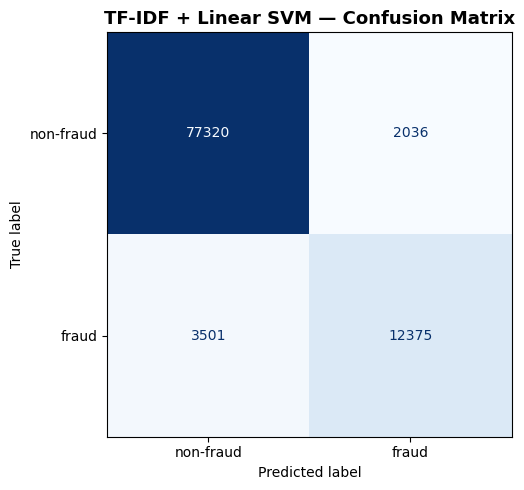

In [15]:
plot_confusion_matrix('TF-IDF + Linear SVM', y_test, svm_test_pred)

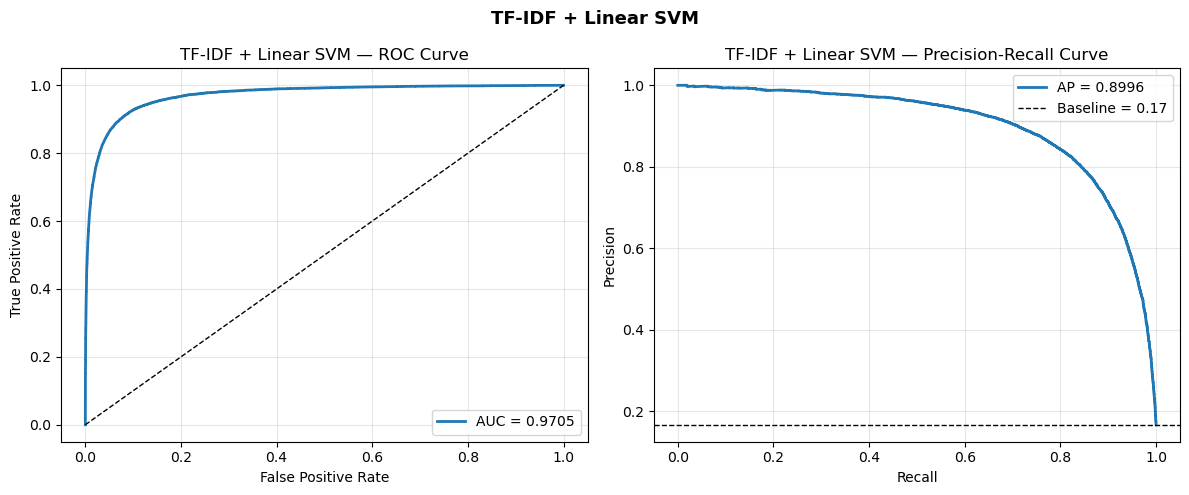

In [16]:
plot_roc_pr('TF-IDF + Linear SVM', y_test, svm_test_prob)

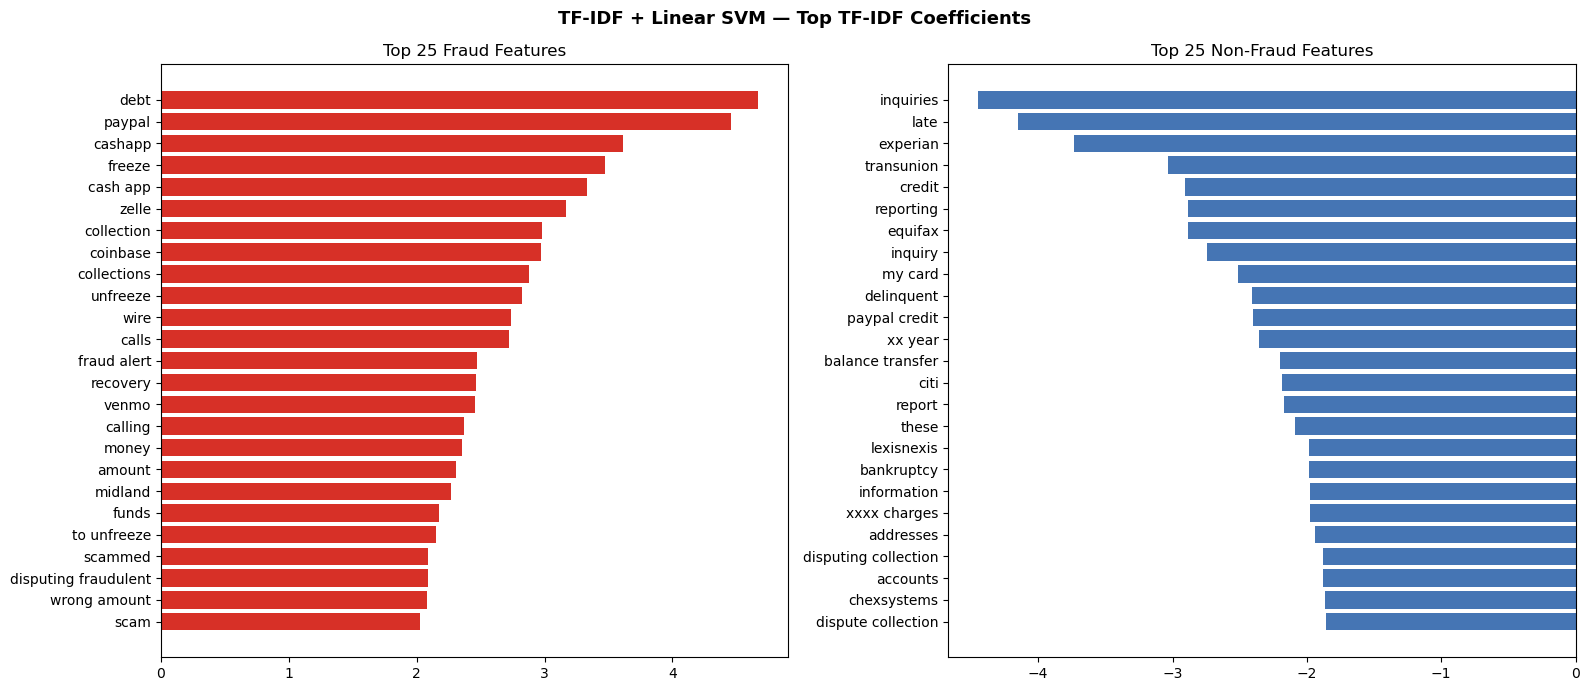

In [18]:
# Feature importance from the underlying LinearSVC
# Extract vectorizer and calibrated classifier from pipeline
svm_vectorizer = svm_pipeline.named_steps['tfidf']
svm_calibrated = svm_pipeline.named_steps['clf']

# get one fitted LinearSVC from the calibrated wrapper
svm_base = svm_calibrated.calibrated_classifiers_[0].estimator

plot_top_features(
    svm_vectorizer,
    svm_base,
    n=25,
    model_name='TF-IDF + Linear SVM'
)

---
## 8. Model 2 — TF-IDF + Logistic Regression

### Hyperparameter rationale
| Parameter | Value | Reason |
|---|---|---|
| `C` | 5.0 | Less regularization than SVM; LR benefits from higher C on large text tasks |
| `solver` | 'saga' | Fastest solver for large sparse data; supports L1 + L2 |
| `penalty` | 'l2' | Standard L2; L1 possible for feature selection but slower |
| `class_weight` | 'balanced' | Addresses 83/17 class imbalance |
| `max_iter` | 1000 | Sufficient with 'saga' solver on normalized TF-IDF features |
| `n_jobs` | -1 | Parallelizes fitting across all cores |

In [19]:
print('Building TF-IDF + Logistic Regression pipeline...')

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf', LogisticRegression(
        C=5.0,
        solver='saga',
        penalty='l2',
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

print('Fitting on training data...')
lr_pipeline.fit(X_train, y_train)
print('Done.')

Building TF-IDF + Logistic Regression pipeline...
Fitting on training data...
Done.


In [20]:
# --- Validation performance ---
lr_val_pred = lr_pipeline.predict(X_val)
lr_val_prob = lr_pipeline.predict_proba(X_val)[:, 1]

lr_val_metrics = evaluate_model(
    'TF-IDF + Logistic Regression',
    y_val, lr_val_pred, lr_val_prob,
    split='Validation'
)


  TF-IDF + Logistic Regression — Validation Set Results
              precision    recall  f1-score   support

   non-fraud       0.98      0.94      0.96     79356
       fraud       0.74      0.89      0.81     15876

    accuracy                           0.93     95232
   macro avg       0.86      0.91      0.88     95232
weighted avg       0.94      0.93      0.93     95232

  ROC-AUC:           0.9710
  Avg Precision:     0.8995


In [21]:
# --- Test performance ---
lr_test_pred = lr_pipeline.predict(X_test)
lr_test_prob = lr_pipeline.predict_proba(X_test)[:, 1]

lr_test_metrics = evaluate_model(
    'TF-IDF + Logistic Regression',
    y_test, lr_test_pred, lr_test_prob,
    split='Test'
)


  TF-IDF + Logistic Regression — Test Set Results
              precision    recall  f1-score   support

   non-fraud       0.98      0.94      0.96     79356
       fraud       0.73      0.89      0.80     15876

    accuracy                           0.93     95232
   macro avg       0.85      0.91      0.88     95232
weighted avg       0.94      0.93      0.93     95232

  ROC-AUC:           0.9706
  Avg Precision:     0.9002


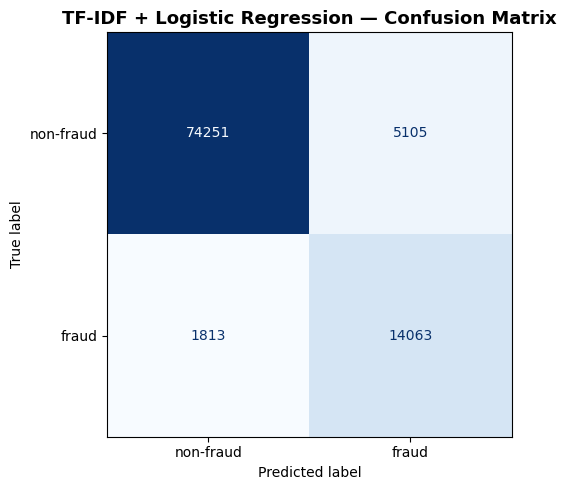

In [22]:
plot_confusion_matrix('TF-IDF + Logistic Regression', y_test, lr_test_pred)

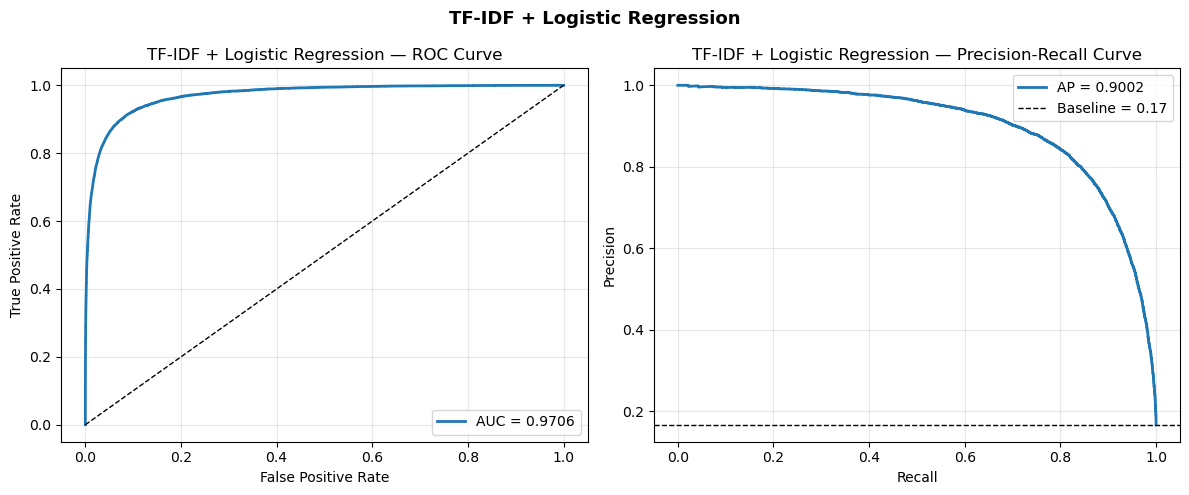

In [23]:
plot_roc_pr('TF-IDF + Logistic Regression', y_test, lr_test_prob)

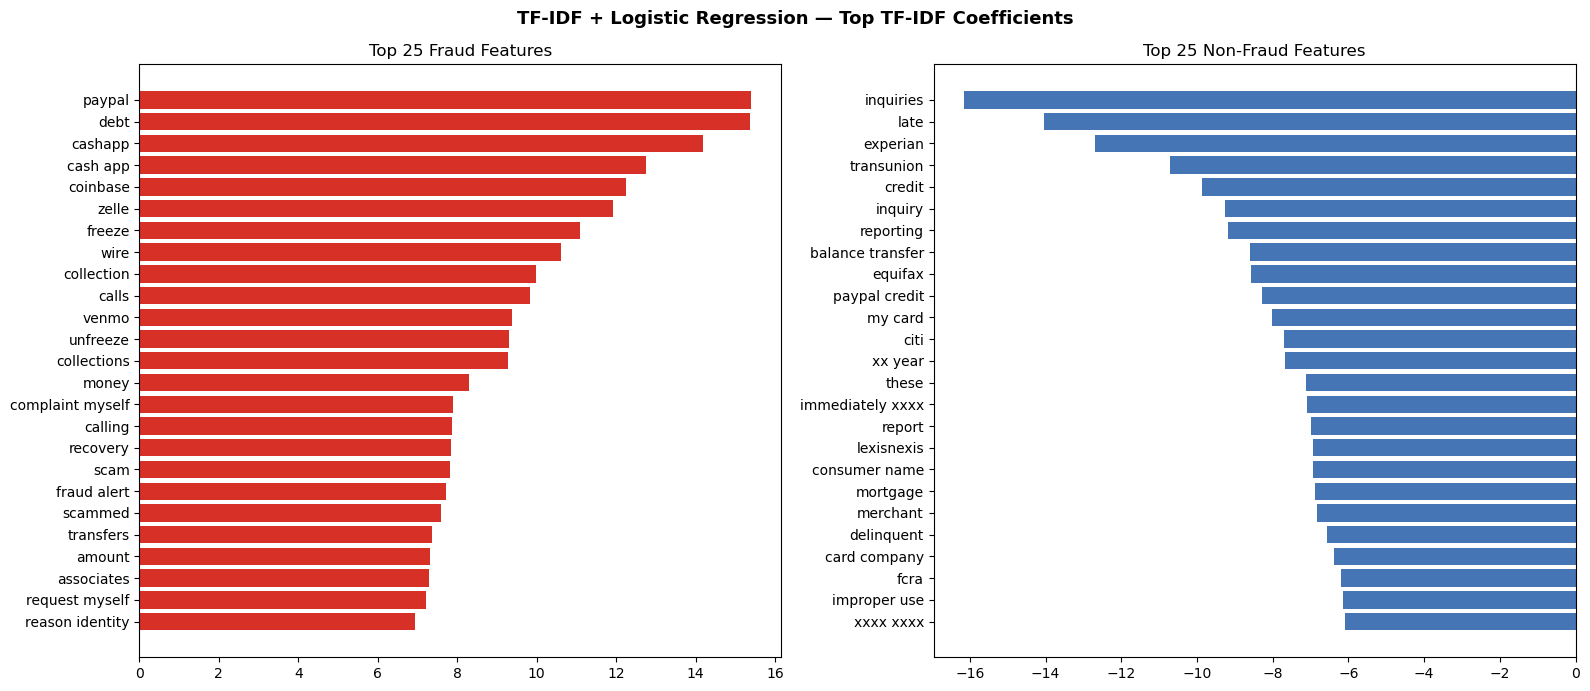

In [24]:
lr_vectorizer = lr_pipeline.named_steps['tfidf']
lr_clf        = lr_pipeline.named_steps['clf']

plot_top_features(lr_vectorizer, lr_clf, n=25, model_name='TF-IDF + Logistic Regression')

---
## 9. Cross-Validation — Stability Check

5-fold stratified CV on the full training set to verify the models are not overfit to the val/test split.

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running 5-fold CV for Linear SVM (F1 macro)...')
svm_cv_scores = cross_val_score(
    svm_pipeline, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=1
)
print(f'  SVM  CV F1-macro: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}')
print(f'  Scores: {np.round(svm_cv_scores, 4)}')

print('\nRunning 5-fold CV for Logistic Regression (F1 macro)...')
lr_cv_scores = cross_val_score(
    lr_pipeline, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=1
)
print(f'  LR   CV F1-macro: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
print(f'  Scores: {np.round(lr_cv_scores, 4)}')

Running 5-fold CV for Linear SVM (F1 macro)...
  SVM  CV F1-macro: 0.8897 ± 0.0006
  Scores: [0.8901 0.8888 0.8905 0.8899 0.8893]

Running 5-fold CV for Logistic Regression (F1 macro)...
  LR   CV F1-macro: 0.8793 ± 0.0011
  Scores: [0.8801 0.88   0.8805 0.8775 0.8786]


---
## 10. Model Comparison

In [27]:
results = pd.DataFrame([
    {
        'Model': 'TF-IDF + Linear SVM',
        'Val F1 (macro)': svm_val_metrics['f1_macro'],
        'Val F1 (fraud)': svm_val_metrics['f1_fraud'],
        'Test F1 (macro)': svm_test_metrics['f1_macro'],
        'Test F1 (fraud)': svm_test_metrics['f1_fraud'],
        'Test ROC-AUC': svm_test_metrics.get('roc_auc', None),
        'Test Avg Precision': svm_test_metrics.get('avg_precision', None),
        'CV F1-macro Mean': svm_cv_scores.mean(),
        'CV F1-macro Std': svm_cv_scores.std(),
    },
    {
        'Model': 'TF-IDF + Logistic Regression',
        'Val F1 (macro)': lr_val_metrics['f1_macro'],
        'Val F1 (fraud)': lr_val_metrics['f1_fraud'],
        'Test F1 (macro)': lr_test_metrics['f1_macro'],
        'Test F1 (fraud)': lr_test_metrics['f1_fraud'],
        'Test ROC-AUC': lr_test_metrics.get('roc_auc', None),
        'Test Avg Precision': lr_test_metrics.get('avg_precision', None),
        'CV F1-macro Mean': lr_cv_scores.mean(),
        'CV F1-macro Std': lr_cv_scores.std(),
    }
])

results = results.set_index('Model').round(4)
print(results.to_string())
results.to_csv(f'{OUTPUT_DIR}/stage1_model_comparison.csv')
print(f'\nSaved to {OUTPUT_DIR}/stage1_model_comparison.csv')

                              Val F1 (macro)  Val F1 (fraud)  Test F1 (macro)  Test F1 (fraud)  Test ROC-AUC  Test Avg Precision  CV F1-macro Mean  CV F1-macro Std
Model                                                                                                                                                              
TF-IDF + Linear SVM                   0.8925          0.8191           0.8913           0.8172        0.9705              0.8996            0.8897           0.0006
TF-IDF + Logistic Regression          0.8815          0.8065           0.8790           0.8026        0.9706              0.9002            0.8793           0.0011

Saved to ../outputs/metrics/stage1_model_comparison.csv


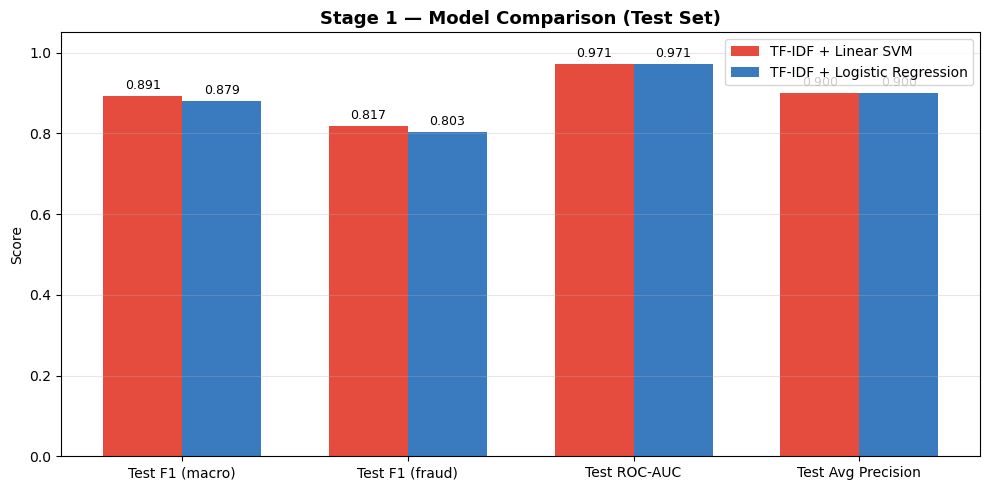

In [28]:
# Visual comparison
metrics_to_plot = ['Test F1 (macro)', 'Test F1 (fraud)', 'Test ROC-AUC', 'Test Avg Precision']
plot_data = results[metrics_to_plot].T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
width = 0.35

bars1 = ax.bar(x - width/2, plot_data.iloc[:, 0], width, label='TF-IDF + Linear SVM',         color='#e64c3d')
bars2 = ax.bar(x + width/2, plot_data.iloc[:, 1], width, label='TF-IDF + Logistic Regression', color='#3a7abf')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Stage 1 — Model Comparison (Test Set)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/stage1_model_comparison.png', dpi=150)
plt.show()

---
## 11. Threshold Tuning

The default threshold (0.5) may not be optimal for imbalanced fraud detection.
Here we find the threshold that maximizes F1 for the fraud class on the validation set.

In [29]:
def find_best_threshold(y_true, y_prob, metric='f1_fraud'):
    thresholds = np.arange(0.10, 0.90, 0.01)
    results = []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, preds, pos_label=1, average='binary', zero_division=0)
        results.append({'threshold': t, 'f1_fraud': f1})
    df_t = pd.DataFrame(results)
    best = df_t.loc[df_t['f1_fraud'].idxmax()]
    return best['threshold'], df_t


# SVM threshold tuning on validation set
svm_best_t, svm_threshold_df = find_best_threshold(y_val, svm_val_prob)
print(f'SVM  best threshold (val): {svm_best_t:.2f}  |  F1 fraud: {svm_threshold_df.loc[svm_threshold_df["threshold"]==svm_best_t, "f1_fraud"].values[0]:.4f}')

# LR threshold tuning on validation set
lr_best_t, lr_threshold_df = find_best_threshold(y_val, lr_val_prob)
print(f'LR   best threshold (val): {lr_best_t:.2f}  |  F1 fraud: {lr_threshold_df.loc[lr_threshold_df["threshold"]==lr_best_t, "f1_fraud"].values[0]:.4f}')

SVM  best threshold (val): 0.38  |  F1 fraud: 0.8243
LR   best threshold (val): 0.68  |  F1 fraud: 0.8236


In [30]:
# Re-evaluate on test set with tuned thresholds
print('\n--- SVM with tuned threshold ---')
svm_tuned_pred = (svm_test_prob >= svm_best_t).astype(int)
evaluate_model('TF-IDF + Linear SVM (tuned threshold)', y_test, svm_tuned_pred, svm_test_prob, split='Test')

print('\n--- LR with tuned threshold ---')
lr_tuned_pred = (lr_test_prob >= lr_best_t).astype(int)
evaluate_model('TF-IDF + Logistic Regression (tuned threshold)', y_test, lr_tuned_pred, lr_test_prob, split='Test')


--- SVM with tuned threshold ---

  TF-IDF + Linear SVM (tuned threshold) — Test Set Results
              precision    recall  f1-score   support

   non-fraud       0.97      0.96      0.96     79356
       fraud       0.81      0.83      0.82     15876

    accuracy                           0.94     95232
   macro avg       0.89      0.90      0.89     95232
weighted avg       0.94      0.94      0.94     95232

  ROC-AUC:           0.9705
  Avg Precision:     0.8996

--- LR with tuned threshold ---

  TF-IDF + Logistic Regression (tuned threshold) — Test Set Results
              precision    recall  f1-score   support

   non-fraud       0.97      0.96      0.96     79356
       fraud       0.82      0.83      0.82     15876

    accuracy                           0.94     95232
   macro avg       0.89      0.90      0.89     95232
weighted avg       0.94      0.94      0.94     95232

  ROC-AUC:           0.9706
  Avg Precision:     0.9002


{'model': 'TF-IDF + Logistic Regression (tuned threshold)',
 'split': 'Test',
 'f1_macro': 0.8927752973152769,
 'f1_fraud': 0.8215770228458918,
 'roc_auc': 0.9706492736261092,
 'avg_precision': 0.9001854256567862}

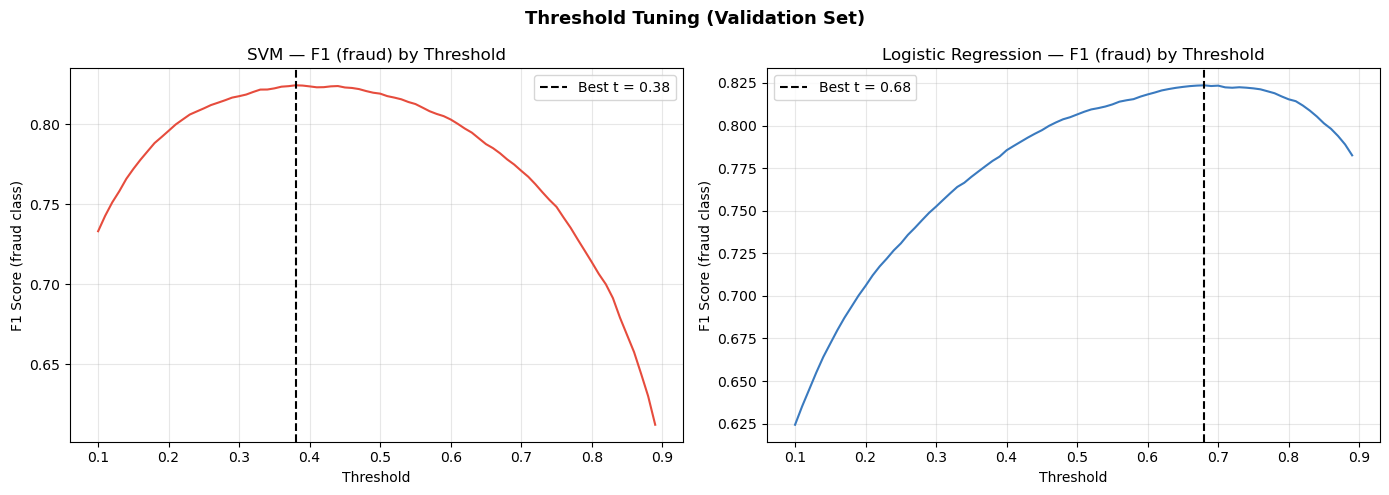

In [31]:
# Threshold curve plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(svm_threshold_df['threshold'], svm_threshold_df['f1_fraud'], color='#e64c3d')
axes[0].axvline(svm_best_t, color='k', linestyle='--', label=f'Best t = {svm_best_t:.2f}')
axes[0].set_title('SVM — F1 (fraud) by Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score (fraud class)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lr_threshold_df['threshold'], lr_threshold_df['f1_fraud'], color='#3a7abf')
axes[1].axvline(lr_best_t, color='k', linestyle='--', label=f'Best t = {lr_best_t:.2f}')
axes[1].set_title('Logistic Regression — F1 (fraud) by Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score (fraud class)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Threshold Tuning (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/threshold_tuning.png', dpi=150)
plt.show()

---
## 12. Save Models

In [32]:
joblib.dump(svm_pipeline, f'{MODEL_DIR}/stage1_svm_pipeline.joblib')
joblib.dump(lr_pipeline,  f'{MODEL_DIR}/stage1_lr_pipeline.joblib')

# Save best thresholds alongside models
thresholds = {'svm': float(svm_best_t), 'lr': float(lr_best_t)}
import json
with open(f'{MODEL_DIR}/stage1_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)

print('Models saved:')
print(f'  {MODEL_DIR}/stage1_svm_pipeline.joblib')
print(f'  {MODEL_DIR}/stage1_lr_pipeline.joblib')
print(f'  {MODEL_DIR}/stage1_thresholds.json')

Models saved:
  ../outputs/models/stage1_svm_pipeline.joblib
  ../outputs/models/stage1_lr_pipeline.joblib
  ../outputs/models/stage1_thresholds.json


---
## 13. Inference Helper

Reusable function for Stage 2 or downstream pipelines.

In [33]:
def predict_fraud(texts, pipeline, threshold=0.5):
    """
    Given a list of complaint narratives and a fitted pipeline,
    returns binary predictions and fraud probability scores.

    Parameters
    ----------
    texts     : list[str] or pd.Series
    pipeline  : fitted sklearn Pipeline
    threshold : float, decision boundary (default 0.5)

    Returns
    -------
    pd.DataFrame with columns: ['text', 'fraud_prob', 'fraud_pred']
    """
    texts = pd.Series(texts).astype(str)
    probs = pipeline.predict_proba(texts)[:, 1]
    preds = (probs >= threshold).astype(int)
    return pd.DataFrame({
        'text': texts.values,
        'fraud_prob': probs,
        'fraud_pred': preds
    })


# Quick sanity check
test_complaints = [
    "Someone stole my identity and opened a credit card in my name without my knowledge.",
    "I was charged a late fee even though my payment was submitted on time.",
    "I received a call from someone claiming to be the IRS demanding immediate payment or arrest.",
    "The bank closed my account without any notice or explanation.",
]

print('LR pipeline predictions:')
print(predict_fraud(test_complaints, lr_pipeline, threshold=lr_best_t).to_string(index=False))

LR pipeline predictions:
                                                                                        text  fraud_prob  fraud_pred
         Someone stole my identity and opened a credit card in my name without my knowledge.    0.816678           1
                      I was charged a late fee even though my payment was submitted on time.    0.144507           0
I received a call from someone claiming to be the IRS demanding immediate payment or arrest.    0.869988           1
                               The bank closed my account without any notice or explanation.    0.454866           0


---
## 14. Next Steps

1. **Choose the best baseline model** based on F1 (fraud) and ROC-AUC from Section 10
2. **Apply Stage 1 predictions** to the full dataset — extract fraud-flagged complaints for Stage 2 training
3. **Advanced models** — DistilBERT / BERT fine-tuning for further uplift
4. **Feature expansion** — add `Product`, `State`, date-derived features to a hybrid model
5. **Error analysis** — inspect false negatives to identify fraud patterns the model misses